# General aim
This notebook was developed as part of the Master’s thesis of June Rossen and is the first of five notebooks used to prepare data for a wind power placement multi-objective optimization.

This first notebook focuses on preparing the data for filtering out technically unfeasible cells for wind power, as well as cells with important socio-environmental considerations that would probably interrupt the licensing process (hereafter "legal" filters). See the *Methods* section of the thesis for justification of the filters and information about the datasets used.

Additionally, the notebook generates several files based on the SSB grid that will be useful in later steps.

## Technical filters
The constraints applied are the following:
- The cells containing the following have their technically suitable area scaled accordingly:
    - sea (mainly computed using nodata in the DEM file, but also with the LULC file for the coastline)
    - lakes
    - snow and glaciers
    - nodata
    - slopes above 30 % 
- Cells with average windspeeds below 4 m/s are discarded 

## Legal filters
The constraints applied are the following:
- No cells containing inhabitants are kept
- Cells intersecting the following areas are removed:
    - Protected areas
    - Nature types with strong environmental value (KU nature types)
    - Wild reindeer areas

## Notebook workflow
- First, the necessary librairies are imported and the data is loaded.
- Then, data are merged one by one to a growing geodataframe.
- Finally, the cells technically unfeasible and "legally compromsied" are removed from the geodataframe, which is then saved as a new file.

In [52]:
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from rasterstats import zonal_stats
from rasterio.mask import mask as rio_mask
import numpy as np
from shapely.geometry import box
from tqdm import tqdm

In [53]:
# Load vector and csv data
NO_grid = gpd.read_file("data/SSB_grid_1km.gpkg")
protected_areas = gpd.read_file("data/protected_areas.gpkg")
nature_types_ku = gpd.read_file("data/nature_types_ku_32633.gpkg")
wild_reindeer = gpd.read_file("data/wild_reindeer.gpkg")
inhabitants = gpd.read_file("data/NOR1000M_POP_2019.csv")

In [54]:
# Paths to raster data
DEM_path = "data/DEM_100m.tif"
#LULC_path = "data/LULC_copernicus.tif"
#new_LULC = "data/LULC_copernicus_units.tif"
new_LULC = "data/land_use_land_cover_50m.tif"
slope_path = "data/slope_100m.tif"
windspeed_path = "data/wind_speed_120.tif"

In [55]:
# To have an overview of the data
display(NO_grid, protected_areas, nature_types_ku, wild_reindeer, inhabitants)

,Join_Count,TARGET_FID,SSBid,ost,nord,CENTROID_X,CENTROID_Y,Shape_Leng,Shape_Area,Komm2016,Fylk2016,geometry
0,1,1196,22450006523000,2245000,6523000,245500.0,6523500.0,4000.0,1000000.0,0111,01,"MULTIPOLYGON (((246000 6523000, 245000 6523000..."
1,1,1397,22460006527000,2246000,6527000,246500.0,6527500.0,4000.0,1000000.0,0111,01,"MULTIPOLYGON (((247000 6527000, 246000 6527000..."
2,1,1447,22460006528000,2246000,6528000,246500.0,6528500.0,4000.0,1000000.0,0111,01,"MULTIPOLYGON (((247000 6528000, 246000 6528000..."
3,1,1497,22460006529000,2246000,6529000,246500.0,6529500.0,4000.0,1000000.0,0111,01,"MULTIPOLYGON (((247000 6529000, 246000 6529000..."
4,1,1598,22470006531000,2247000,6531000,247500.0,6531500.0,4000.0,1000000.0,0111,01,"MULTIPOLYGON (((248000 6531000, 247000 6531000..."
...,...,...,...,...,...,...,...,...,...,...,...,...
478635,0,656,31050007913000,3105000,7913000,1105500.0,7913500.0,4000.0,1000000.0,2002,20,"MULTIPOLYGON (((1106000 7913000, 1105000 79130..."
478636,0,703,31020007914000,3102000,7914000,1102500.0,7914500.0,4000.0,1000000.0,2002,20,"MULTIPOLYGON (((1103000 7914000, 1102000 79140..."
478637,0,704,31030007914000,3103000,7914000,1103500.0,7914500.0,4000.0,1000000.0,2002,20,"MULTIPOLYGON (((1104000 7914000, 1103000 79140..."
478638,0,751,31000007915000,3100000,7915000,1100500.0,7915500.0,4000.0,1000000.0,2002,20,"MULTIPOLYGON (((1101000 7915000, 1100000 79150..."


,OBJECTID,faktaark,uuid,identifikasjon_lokalId,identifikasjon_navnerom,kommune,forvaltningsmyndighet,forvaltningsmyndighetType,cddaId,førstegangVernet,...,skogvern,tiltaksbehov,truetVurdering,vernedato,verneform,verneformAggregert,verneforskrift,verneplan,skjøtselplanDato,geometry
0,1,https://faktaark.naturbase.no/?id=VV00003155,{C763DB68-4895-4089-B4DF-316F961951EF},VV00003155,https://www.miljodirektoratet.no/naturbase,3025,Statsforvalteren i Oslo og Viken,statsforvalter,555589640,None,...,ja,ikkeBehov,ikkeTruet,None,naturreservat,naturreservat,https://lovdata.no/forskrift/2015-03-20-232,skogvern,None,"MULTIPOLYGON (((239971.68 6637023.22, 240403.9..."
1,2,https://faktaark.naturbase.no/?id=VV00000825,{C80C6BB8-7AA4-461B-9139-C1AB255F4ED6},VV00000825,https://www.miljodirektoratet.no/naturbase,1112,Statsforvalteren i Rogaland,statsforvalter,155680,None,...,ja,ikkeVurdert,,None,naturreservat,naturreservat,https://lovdata.no/forskrift/1984-12-21-2207,verneplanLøvskog,None,"MULTIPOLYGON (((6643.78 6506797.01, 6549.1 650..."
2,3,https://faktaark.naturbase.no/?id=VV00002765,{0F4EFEAB-FD4C-4C29-BC1F-C04CBB3A1A6D},VV00002765,https://www.miljodirektoratet.no/naturbase,5025,Verneområdestyret for Skardsfjella-Hyllingsdal...,verneområdestyre,395337,None,...,ja,ikkeVurdert,ikkeVurdert,None,naturreservat,naturreservat,https://lovdata.no/forskrift/2009-01-09-25,verneplanVåtmark,None,"MULTIPOLYGON (((337925.33 6963553.45, 338073.2..."
3,4,https://faktaark.naturbase.no/?id=VV00001473,{9D5B425C-61BD-4BB1-B243-321422420A21},VV00001473,https://www.miljodirektoratet.no/naturbase,4226,Hægebostad kommune,kommune,155566,None,...,ja,behov,truet,None,naturreservat,naturreservat,https://lovdata.no/forskrift/1978-12-22-43,verneplanLøvskog,None,"MULTIPOLYGON (((45864.87 6509569.2, 45839.98 6..."
4,5,https://faktaark.naturbase.no/?id=VV00003508,{6A2A4074-DD5D-4E0C-97DB-35B783C4B32B},VV00003508,https://www.miljodirektoratet.no/naturbase,3003,Statsforvalteren i Oslo og Viken,statsforvalter,555692032,None,...,ja,ikkeVurdert,ikkeVurdert,None,naturreservat,naturreservat,https://lovdata.no/forskrift/2020-06-23-1312,skogvern,None,"MULTIPOLYGON (((279622.05 6589585.07, 279636.2..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3350,3351,https://faktaark.naturbase.no/?id=VV00003845,{AD12FC68-7ED0-40FD-B5A7-867E2623C300},VV00003845,https://www.miljodirektoratet.no/naturbase,4206,None,statsforvalter,None,None,...,ja,behov,truet,None,naturreservat,naturreservat,https://lovdata.no/forskrift/2023-06-20-1031,skogvern,None,"MULTIPOLYGON (((12043.06 6480741.25, 12043.44 ..."
3351,3352,https://faktaark.naturbase.no/?id=VV00003844,{BCFDB2C2-67AF-4A01-B243-18B496FE9D2F},VV00003844,https://www.miljodirektoratet.no/naturbase,4201,None,statsforvalter,None,None,...,ja,ikkeBehov,ikkeTruet,None,naturreservat,naturreservat,https://lovdata.no/forskrift/2023-06-20-1037,skogvern,None,"MULTIPOLYGON (((161563.21 6529019.26, 161564.3..."
3352,3353,https://faktaark.naturbase.no/?id=VV00003846,{1663F1EA-F184-4C07-A058-4D334962CB49},VV00003846,https://www.miljodirektoratet.no/naturbase,"4223,4204",None,statsforvalter,None,None,...,ja,ikkeBehov,ikkeTruet,None,naturreservat,naturreservat,https://lovdata.no/forskrift/2023-06-20-1032,skogvern,None,"MULTIPOLYGON (((88136.33 6475827.45, 88088 647..."
3353,3354,https://faktaark.naturbase.no/?id=VV00003843,{DF7E6F0F-05E1-406C-9DC1-164FDB2574D0},VV00003843,https://www.miljodirektoratet.no/naturbase,4212,None,statsforvalter,None,None,...,ja,ikkeBehov,ikkeTruet,None,naturreservat,naturreservat,https://lovdata.no/forskrift/2023-06-20-1035,skogvern,None,"MULTIPOLYGON (((141512.37 6521014.87, 141582.8..."


,verdikategori,faktaark,geometry
0,Svært stor verdi,https://faktaark.naturbase.no/?id=VKU-UN-NINFP...,"MULTIPOLYGON (((191042.961 6581625.648, 191046..."
1,Svært stor verdi,https://faktaark.naturbase.no/?id=VKU-UN-NINFP...,"MULTIPOLYGON (((191451.842 6582116.883, 191435..."
2,Svært stor verdi,https://faktaark.naturbase.no/?id=VKU-UN-NINFP...,"MULTIPOLYGON (((115940.484 6479825.643, 115941..."
3,Svært stor verdi,https://faktaark.naturbase.no/?id=VKU-UN-NINFP...,"MULTIPOLYGON (((-2762.279 6704011.89, -2755.77..."
4,Svært stor verdi,https://faktaark.naturbase.no/?id=VKU-UN-NINFP...,"MULTIPOLYGON (((285414.786 7057427.933, 285409..."
...,...,...,...
258297,Svært stor verdi,https://faktaark.naturbase.no/?id=VKU-UN-NINFP...,"MULTIPOLYGON (((211917.1 6549421.197, 211917.0..."
258298,Svært stor verdi,https://faktaark.naturbase.no/?id=VKU-UN-NINFP...,"MULTIPOLYGON (((212338.586 6550212.686, 212338..."
258299,Svært stor verdi,https://faktaark.naturbase.no/?id=VKU-UN-NINFP...,"MULTIPOLYGON (((212683.864 6549349.527, 212683..."
258300,Svært stor verdi,https://faktaark.naturbase.no/?id=VKU-UN-NINFP...,"MULTIPOLYGON (((212573.638 6549325.755, 212573..."


,OBJECTID,funksjon,funksjonsperiode,omradenavn,villreinopphav,villreinregioneuropeisk,geometry
0,1,trekkområde,heleÅret,Setesdal-Ryfylke trekkvei,None,Sør,"MULTIPOLYGON (((14191.416 6619837.064, 16690.7..."
1,2,trekkområde,heleÅret,Setesdal-Austhei trekkvei,None,Sør,"MULTIPOLYGON (((102343.471 6570434.225, 102362..."
2,3,trekkområde,ukjent,Vest-Jotunheimen trekkområde,None,Nei,"MULTIPOLYGON (((123936.461 6820589.485, 123921..."
3,4,trekkområde,heleÅret,Setesdal-Austhei trekkvei,None,Sør,"MULTIPOLYGON (((85809.252 6633598.873, 85618.2..."
4,5,trekkområde,høstVinter,Blefjell trekkvei,None,Nei,"MULTIPOLYGON (((166377.32 6664597.159, 166346...."
...,...,...,...,...,...,...,...
1055,1056,trekkområde,heleÅret,Setesdal-Ryfylke-Setesdal-Austhei trekkområde,None,Sør,"MULTIPOLYGON (((76458.934 6641415.702, 76595.8..."
1056,1057,trekkområde,heleÅret,Setesdal-Ryfylke-Setesdal-Austhei trekkområde,None,Sør,"MULTIPOLYGON (((84358.613 6642069.275, 84039.3..."
1057,1058,trekkområde,heleÅret,Setesdal-Ryfylke-Setesdal-Austhei trekkområde,None,Sør,"MULTIPOLYGON (((72454.684 6632940.181, 71428.3..."
1058,1059,trekkområde,heleÅret,Setesdal-Ryfylke-Setesdal-Austhei trekkområde,None,Sør,"MULTIPOLYGON (((69331.704 6631679.37, 69515.33..."


,SSBID1000M,pop_tot,pop_mal,pop_fem,pop_ave2
0,19250006616000,9,6,3,48
1,19250006617000,125,69,56,39
2,19250006618000,35,18,17,52
3,19260006616000,4,2,2,0
4,19260006617000,23,13,10,40
...,...,...,...,...,...
54983,30960007887000,376,184,192,44
54984,30970007886000,300,154,146,42
54985,30970007887000,857,472,385,44
54986,30980007886000,176,97,79,43


In [56]:
# Remove unnecessary columns and adjust a few things (type of some columns)
NO_grid.drop(columns=["Join_Count", "TARGET_FID", "ost", "nord", "CENTROID_X", "CENTROID_Y", "Shape_Leng", "Shape_Area"], inplace=True)
NO_grid["SSBid"] = NO_grid["SSBid"].astype(int)

protected_areas = protected_areas[["geometry"]]
nature_types_ku = nature_types_ku[["geometry"]]
wild_reindeer = wild_reindeer[["geometry"]]

inhabitants = inhabitants[["SSBID1000M", "pop_tot"]].astype(int)

# Technical filters

## Calculate mean elevation over each cell

I was going to use zonal_statistics from rasterstats but it was going to take over one hour, so I went for rasterizing the cells and then using numpy to make the process faster

In [57]:
# 1-2 min

# Fetch the relevant information from the DEM file and adjust the CRS of the NO_grid to the one of the DEM
with rasterio.open(DEM_path) as src:
    print("Nodata value:", src.nodata)  # print nodata and crs of the DEM raster
    print("CRS:", src.crs)
    
    NO_grid = NO_grid.to_crs(src.crs)   # reproject NO_grid to the same CRS

    dem = src.read(1, masked=True)   # masked array: keeps information on which pixels are nodata (nodata = TRUE)
    transform = src.transform        # affine transform: links raster grid to real-world coordinates, will use this transform for rasterizing our vector grid
    shape = dem.shape                # (rows, cols) of the raster, will use this shape for rasterizing our vector grid

# Rasterize polygons into an ID map
# Each pixel gets the index of the polygon it falls inside, or -1 for background
shapes = [(geom, idx) for idx, geom in enumerate(NO_grid.geometry)]
poly_raster = rasterize(
    shapes,
    out_shape=shape,
    transform=transform,
    fill=-1,          # background value (no polygon)
    dtype="int32"
)

# Extract DEM values only where they are valid (not nodata)
valid_mask = ~dem.mask               # True = valid DEM pixel
dem_vals = dem.data[valid_mask]      # valid elevation values
poly_ids = poly_raster[valid_mask]   # polygon ID at those valid pixels

# Remove background pixels (those not inside any polygon)
mask = poly_ids != -1
dem_vals = dem_vals[mask]
poly_ids = poly_ids[mask]

# Compute mean DEM value per polygon ID
sums = np.bincount(poly_ids, weights=dem_vals)   # total elevation per polygon
counts = np.bincount(poly_ids)                   # number of pixels per polygon

means_arr = np.divide(
    sums, counts,
    out=np.full_like(sums, np.nan, dtype=float),  # fill with NaN where invalid
    where=counts != 0                             # only divide if count > 0
)

# Attach results back to GeoDataFrame
NO_grid["mean_elevation"] = np.nan

# Map polygon IDs to mean elevation
means_dict = {pid: means_arr[pid] for pid in np.unique(poly_ids)}

# Assign using .map
NO_grid["mean_elevation"] = NO_grid.index.map(means_dict).astype(float)

Nodata value: nan
CRS: EPSG:25833


In [ ]:
# Filter out the nodata cells, assuming they mostly represent sea pixels, which are out of the scope of the study.
NO_grid = NO_grid.dropna(subset=["mean_elevation"])

# Save the resulting geodataframe in a file for future use. Uncomment if file needed and not provided
#NO_grid.to_file("data/SSB_land.gpkg", driver="GPKG")

<Axes: >

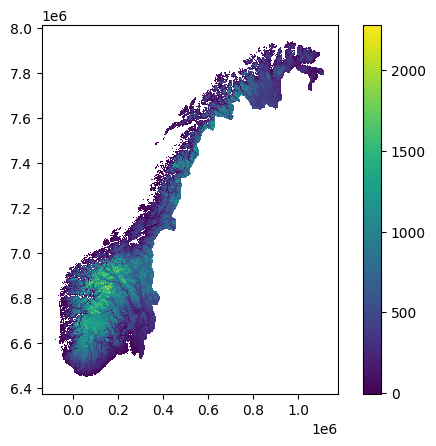

In [8]:
# 1-2 min
NO_grid.plot("mean_elevation", legend=True)

## Calculate mean LULC classes over each cell
And add a "percentage not usable" based on permanent water bodies, ice and snow, and nodata.

The first cell needs to be run only if the only available LULC is the original Copernicus raster. The cell reduces the number of types of forest from 6 to 2, based on the values of the cells (111 to 116 and 121 to 126), by doing a integer division by 10. --> if the desired LULC file is already available, skip the first cell.

The third cell uses rasterstats this time by simplicity, even if it takes longer. It can also be skipped if the file containing the dataframe of statistics on LULC cover is provided: this can save up to 2h. 

In [9]:
"""
# Specific to Copernicus raster: divide all values by ten, in order to merge the types of forests together
with rasterio.open(LULC_path) as src:
    profile = src.profile
    data = src.read(1)

    # Divide values by 10 (integer division)
    new_data = data // 10

    # Update dtype if necessary
    profile.update(dtype=rasterio.int32)

    # Save the modified raster
    with rasterio.open(new_LULC, "w", **profile) as dst:
        dst.write(new_data.astype(profile["dtype"]), 1)
"""

'\n# Specific to Copernicus raster: divide all values by ten, in order to merge the types of forests together\nwith rasterio.open(LULC_path) as src:\n    profile = src.profile\n    data = src.read(1)\n\n    # Divide values by 10 (integer division)\n    new_data = data // 10\n\n    # Update dtype if necessary\n    profile.update(dtype=rasterio.int32)\n\n    # Save the modified raster\n    with rasterio.open(new_LULC, "w", **profile) as dst:\n        dst.write(new_data.astype(profile["dtype"]), 1)\n'

In [10]:
# Fetch the relevant information from the LULC file and adjust the CRS of the NO_grid to the one of the LULC file
with rasterio.open(new_LULC) as src:
    print("Nodata value:", src.nodata)  # print nodata and crs of the LULC raster
    print("CRS:", src.crs)
    NO_grid = NO_grid.to_crs(src.crs)   # reproject NO_grid to the same CRS


Nodata value: 127.0
CRS: EPSG:25833


In [ ]:
# 2-3 hours

"""
# Do zonal statistics using rasterstats

# Count the number of each LULC class pixels for each polygon
stats = zonal_stats(
    vectors = NO_grid,
    raster = new_LULC,
    categorical = True,     # each value of LULC is a different category, each of which will be counted
    all_touched=False,      # only count cells whose center is inside polygon
    geojson_out=False,      # don’t return full geometries
)

# If there is nodata, it means the cover of this class on this cell is 0
lulc_stats = pd.DataFrame(stats).fillna(0).astype(float)

# Reorder lulc_stats columns numerically
lulc_stats = lulc_stats.reindex(sorted(lulc_stats.columns), axis=1)
lulc_stats.rename(columns={col: f"LULC_{col}" for col in lulc_stats.columns}, inplace=True)

# Compute percentages for each LULC category
lulc_cols = lulc_stats.columns
row_sums = lulc_stats.sum(axis=1)  # total pixels per polygon
pixels_per_cell = max(row_sums)
for col in lulc_cols:
    lulc_stats[col] = lulc_stats[col] / pixels_per_cell     # divide by the max theoretical value of pixels per cell (in our case 1600), and not row_sums, because if there is some nodata leading to less pixels, then we assume we cannot place a turbine there. 

lulc_stats = pd.concat([NO_grid["SSBid"].reset_index(drop=True), lulc_stats], axis=1)   # relink to the SSBid "index". Use .reset_index so that they align by line number and not by index number
lulc_stats.to_csv("data/land_use_land_cover_50m_stats.csv")
"""

'\n# Do zonal statistics using rasterstats\n\n# Count the number of each LULC class pixels for each polygon\nstats = zonal_stats(\n    vectors = NO_grid,\n    raster = new_LULC,\n    categorical = True,     # each value of LULC is a different category, each of which will be counted\n    all_touched=False,      # only count cells whose center is inside polygon\n    geojson_out=False,      # don’t return full geometries\n)\n\n# If there is nodata, it means the cover of this class on this cell is 0\nlulc_stats = pd.DataFrame(stats).fillna(0).astype(float)\n\n# Reorder lulc_stats columns numerically\nlulc_stats = lulc_stats.reindex(sorted(lulc_stats.columns), axis=1)\nlulc_stats.rename(columns={col: f"LULC_{col}" for col in lulc_stats.columns}, inplace=True)\n\n# Compute percentages for each LULC category\nlulc_cols = lulc_stats.columns\nrow_sums = lulc_stats.sum(axis=1)  # total pixels per polygon\npixels_per_cell = max(row_sums)\nfor col in lulc_cols:\n    lulc_stats[col] = lulc_stats[co

In [ ]:
lulc_stats = gpd.read_file("data/land_use_land_cover_50m_stats.csv")

# Need to convert values from type object to type float. Convert SSBid to int
lulc_stats = lulc_stats.astype(float)
lulc_stats["SSBid"] = lulc_stats["SSBid"].astype(int)

# Some of the kept SSB cells had no overlap with the land_use_land_cover_50m, so there are lines containing only zeros, which will be misleading when calculating the percentage of unfeasible LULC type.
# Identify the fraction of cells not covered by data from the LULC. Also identify the fraction of cells that containt non-feasible LULC. Add everything into one indicator of unusable area fraction.
value_columns = lulc_stats.columns[2:]
row_sums = lulc_stats[value_columns].sum(axis=1)
#nodata_mask = row_sums < 0.1
#lulc_stats.loc[nodata_mask, value_columns] = np.nan
lulc_stats["not_covered_by_lulc"] = 1-row_sums

# Merge by SSBid to avoid any potential problems with indices
NO_grid = NO_grid.merge(
    lulc_stats[["SSBid", "LULC_15", "LULC_16", "LULC_17", "LULC_18", "not_covered_by_lulc"]],
    on="SSBid",
    how="left"
)

NO_grid["pct_NoGo_lulc"] = NO_grid["LULC_15"] + NO_grid["LULC_16"] + NO_grid["LULC_17"] + NO_grid["LULC_18"] + NO_grid["not_covered_by_lulc"]
                # percentages with snow glacier,    permanent freshwater,       ocean,          not mapped,     and out of the extent of the LULC

# If the value is NaN, it means there are no valid LULC categories and the cell should be discarded.
NO_grid = NO_grid.dropna(subset=['pct_NoGo_lulc']).reset_index(drop=True)

In [13]:
lulc_stats

,field_1,SSBid,LULC_1,LULC_2,LULC_3,LULC_4,LULC_5,LULC_6,LULC_7,LULC_8,...,LULC_10,LULC_11,LULC_12,LULC_13,LULC_14,LULC_15,LULC_16,LULC_17,LULC_18,not_covered_by_lulc
0,0.0,22490006594000,0.000000,0.000000,0.000000,0.003750,0.010625,0.006875,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,0.978750,0.0,0.00
1,1.0,22490006595000,0.028125,0.000000,0.130625,0.071875,0.021250,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,0.748125,0.0,0.00
2,2.0,22490006596000,0.076250,0.024375,0.043125,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,0.776875,0.0,0.00
3,3.0,22490006597000,0.000000,0.006250,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,0.989375,0.0,0.00
4,4.0,22990006532000,0.143125,0.000000,0.764375,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0525,0.000000,0.0,0.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
356680,356680.0,31080007818000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,0.000000,0.0,1.00
356681,356681.0,31060007819000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,0.000000,0.0,1.00
356682,356682.0,31070007819000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,0.000000,0.0,1.00
356683,356683.0,31060007820000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,0.000000,0.0,1.00


In [14]:
NO_grid

,SSBid,Komm2016,Fylk2016,geometry,mean_elevation,LULC_15,LULC_16,LULC_17,LULC_18,not_covered_by_lulc,pct_NoGo_lulc
0,22490006594000,0104,01,"MULTIPOLYGON (((250000 6594000, 249000 6594000...",8.221429,0.0,0.0000,0.978750,0.0,0.00,0.978750
1,22490006595000,0104,01,"MULTIPOLYGON (((250000 6595000, 249000 6595000...",15.658333,0.0,0.0000,0.748125,0.0,0.00,0.748125
2,22490006596000,0104,01,"MULTIPOLYGON (((250000 6596000, 249000 6596000...",5.277778,0.0,0.0000,0.776875,0.0,0.00,0.776875
3,22490006597000,0104,01,"MULTIPOLYGON (((250000 6597000, 249000 6597000...",1.975000,0.0,0.0000,0.989375,0.0,0.00,0.989375
4,22990006532000,0101,01,"MULTIPOLYGON (((300000 6532000, 299000 6532000...",111.280657,0.0,0.0525,0.000000,0.0,0.04,0.092500
...,...,...,...,...,...,...,...,...,...,...,...
356680,31080007818000,2030,20,"MULTIPOLYGON (((1109000 7818000, 1108000 78180...",207.563000,0.0,0.0000,0.000000,0.0,1.00,1.000000
356681,31060007819000,2030,20,"MULTIPOLYGON (((1107000 7819000, 1106000 78190...",88.914000,0.0,0.0000,0.000000,0.0,1.00,1.000000
356682,31070007819000,2030,20,"MULTIPOLYGON (((1108000 7819000, 1107000 78190...",119.405999,0.0,0.0000,0.000000,0.0,1.00,1.000000
356683,31060007820000,2030,20,"MULTIPOLYGON (((1107000 7820000, 1106000 78200...",67.903500,0.0,0.0000,0.000000,0.0,1.00,1.000000


In [15]:
NO_grid.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 356685 entries, 0 to 356684
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --------------   -----   
 0   SSBid                356685 non-null  int64   
 1   Komm2016             356685 non-null  object  
 2   Fylk2016             356685 non-null  object  
 3   geometry             356685 non-null  geometry
 4   mean_elevation       356685 non-null  float64 
 5   LULC_15              356685 non-null  float64 
 6   LULC_16              356685 non-null  float64 
 7   LULC_17              356685 non-null  float64 
 8   LULC_18              356685 non-null  float64 
 9   not_covered_by_lulc  356685 non-null  float64 
 10  pct_NoGo_lulc        356685 non-null  float64 
dtypes: float64(7), geometry(1), int64(1), object(2)
memory usage: 29.9+ MB


In [17]:
# With Copernicus LULC
"""
lulc_stats = gpd.read_file("data/spatial_data/LULC_copernicus_stats.csv")

# Need to convert values from type object to type float. Do the same for SSBid for simplicity's sake
lulc_stats = lulc_stats.astype(float)
NO_grid["SSBid"] = NO_grid["SSBid"].astype(float)

# Merge by SSBid to avoid any potential problems with indices
NO_grid = NO_grid.merge(
    lulc_stats[["SSBid", "LULC_7", "LULC_8", "LULC_20", "LULC_25"]],
    on="SSBid",
    how="left"
)

NO_grid["pct_NoGo_lulc"] = NO_grid["LULC_7"] + NO_grid["LULC_8"] + NO_grid["LULC_20"] + NO_grid["LULC_25"]
                # percentages with snow/ice,    permanent water bodies,     open sea,       and logged in nodata
"""

'\nlulc_stats = gpd.read_file("data/spatial_data/LULC_copernicus_stats.csv")\n\n# Need to convert values from type object to type float. Do the same for SSBid for simplicity\'s sake\nlulc_stats = lulc_stats.astype(float)\nNO_grid["SSBid"] = NO_grid["SSBid"].astype(float)\n\n# Merge by SSBid to avoid any potential problems with indices\nNO_grid = NO_grid.merge(\n    lulc_stats[["SSBid", "LULC_7", "LULC_8", "LULC_20", "LULC_25"]],\n    on="SSBid",\n    how="left"\n)\n\nNO_grid["pct_NoGo_lulc"] = NO_grid["LULC_7"] + NO_grid["LULC_8"] + NO_grid["LULC_20"] + NO_grid["LULC_25"]\n                # percentages with snow/ice,    permanent water bodies,     open sea,       and logged in nodata\n'

## Calculate percentage slope over 30% over each cell
Slope raster previously calculated using QGIS and the DEM file.

The cell loops over the cells of the SSB grid, cropping the extent of the slope raster layer to avoid overloading the memory, handles nodata and nan values, and then sums the number of pixels above 30, and divides that by the total number of valid pixels to get the average of pixels above 30% per grid cell.

In [ ]:
# Prepare output column
NO_grid["pct_slope_over_30"] = np.nan

# Fetch the relevant information from the slope file and adjust the CRS of the NO_grid to the one of the slope file
with rasterio.open(slope_path) as src:
    slope_data = src.read(1, masked=True)  # just to get metadata
    raster_crs = src.crs
    transform = src.transform
    print("Nodata value:", src.nodata)
    print("CRS:", raster_crs)

    NO_grid = NO_grid.to_crs(raster_crs)

    # Loop over polygons
    for i, geom in tqdm(NO_grid.iterrows(), total=len(NO_grid)):
        try:
            # Mask raster to the polygon, the way it works:
            #   1.    It computes which raster cells overlap the polygon’s bounding box.
                        # --> in our case, it should include 11x11 = 121 slope cells, as the slope raster has a resolution of 100m, the SSB grid of 1000m, and they are decentered
            #   2.    It creates a boolean mask for that cropped region, marking which pixels are inside vs. outside the geometry, with "inside" being defined as "the center of the pixel is inside the polygon"
            #   3.    It applies that mask to the raster values, setting “outside” pixels to the raster’s nodata value.
                        # --> in our case, because the raster and vector grids are decentered, only 10x10 = 100 pixels will have valid values,
                        # i.e. a 1 pixel width strip will be removed both from the height and width of the SSB grid cells
                        # However, some additional pixels might be nodata also, around fjords and the sea for instance. Hence the strange definition of max_number_pixels
            out_image, out_transform = rio_mask(src, [geom.geometry], crop=True)
            data = out_image[0]

            # Similar logic to pct_NoGo_lulc when part of the SSB grid cell is over some NoData in the slope raster:
            #   need to use the maximum number of slope pixels (in our case 100) as the denominator (and not the number of valid pixels), otherwise the pct_slope_over_30 will be skewed around fjords and the sea
            # The implementation is a bit strange in this case, it's based on the logic of the raster and vector grids being decentered
            max_number_pixels = np.square(np.sqrt(data.size) - 1 )
            
            # Uncomment to check if the assumption for max_number_pixels is correct. If using a different resolution slope raster, change 100 to the assumed max_number_pixels.
            #if max_number_pixels != 100:
            #    print("Pixel at \t", i, " = ", number_pixels)
                
            # Remove nodata
            if src.nodata is not None:
                valid_mask = data != src.nodata
                data = data[valid_mask]

            data = data[~np.isnan(data)]  # handle NaN if any

            if len(data) == 0:
                pct = np.nan
            else:
                pct = np.sum(data > 30) / max_number_pixels

            NO_grid.at[i, "pct_slope_over_30"] = pct

        except Exception as e:
            print(f"Polygon {i} failed: {e}")
            NO_grid.at[i, "pct_slope_over_30"] = np.nan


Nodata value: -9999.0
CRS: EPSG:25833


100%|██████████| 356685/356685 [04:52<00:00, 1218.18it/s]


## Calculate percentage of technically unfeasible area over each cell, due to complicated LULC classes and/or slope above 30% 
As a basic estimate, simply add the percentages due to complicated LULC and slope. Indeed, lakes and sea are at 0% slope in any case, so no risk of double counting. For the snow/ice, there is a risk of double counting, but if there is snow at 30% + slope, we probably don't want a turbine just under that in case there is avalanche risk, so it's probably better to be conservative and in the worst case double count some complex areas.

Additionaly, be careful to not pass a percentage over 100%.

In [19]:
pct_NoGo = NO_grid["pct_slope_over_30"] + NO_grid["pct_NoGo_lulc"]
NO_grid["pct_NoGo"] = pct_NoGo.clip(upper=1)

## Add average windspeed to the geodataframe
The average windspeed file has a resolution of 1km x 1km also, so simply sample the value at the centroid of each SSB grid cell.

In [20]:
# Fetch the relevant information from the average windspeed file and adjust the CRS of the NO_grid to the one of the windspeed file
# Sample the windspeed values at the centroid of each SSB grid cell
with rasterio.open(windspeed_path) as src:
    nodata = src.nodata
    print("Nodata value:", nodata)
    print("CRS:", src.crs)
    if NO_grid.crs != src.crs:
        NO_grid = NO_grid.to_crs(src.crs)

    coords = [(geom.centroid.x, geom.centroid.y) for geom in NO_grid.geometry]
    wind_values = [val[0] for val in src.sample(coords)]

NO_grid["avg_windspeed"] = [np.nan if v == nodata else v for v in wind_values]

Nodata value: -1.0
CRS: EPSG:32633


# Legal filters

## Add the number of inhabitants to the gdf
If the value is NaN, it implies there are no inhabitants, so remplace by 0.

Save a file with all SSB cells containing inhabitants. Uncomment if file needed and not provided.

In [59]:
# Merge the geodataframe and dataframe
NO_grid = NO_grid.merge(
    inhabitants,
    left_on="SSBid",        # Column in the gdf
    right_on="SSBID1000M",  # Column in the df
    how="left"              # Use 'left' to keep all rows from the gdf
)

# Remove unnecessary columns and fill na with 0 for the number of inhabitants
NO_grid.drop(columns=["SSBID1000M"], inplace=True)
NO_grid["pop_tot"] = NO_grid["pop_tot"].fillna(0).astype(int)

In [ ]:
#NO_grid_populated = NO_grid[NO_grid["pop_tot"] > 0].copy()
#NO_grid_populated = NO_grid_populated[["SSBid", "pop_tot", "geometry"]]
#NO_grid_populated.to_file("data/SSB_populated.gpkg", driver="GPKG")
#display(NO_grid_populated)             # notice that there are 54'987 cells instead of 54'988. One of the cells containing inhabitants was removed because of NoData within the DEM raster

,SSBid,pop_tot,geometry
1,22490006595000,2,"MULTIPOLYGON (((250000 6595000, 249000 6595000..."
4,22990006532000,4,"MULTIPOLYGON (((300000 6532000, 299000 6532000..."
7,22980006533000,2,"MULTIPOLYGON (((299000 6533000, 298000 6533000..."
8,22990006533000,4,"MULTIPOLYGON (((300000 6533000, 299000 6533000..."
12,22990006534000,16,"MULTIPOLYGON (((300000 6534000, 299000 6534000..."
...,...,...,...
355711,30970007887000,857,"MULTIPOLYGON (((1098000 7887000, 1097000 78870..."
355712,30980007887000,137,"MULTIPOLYGON (((1099000 7887000, 1098000 78870..."
355757,30940007888000,2,"MULTIPOLYGON (((1095000 7888000, 1094000 78880..."
356009,30560007895000,1,"MULTIPOLYGON (((1057000 7895000, 1056000 78950..."


# Remove cells

## Remove cells technically unfeasible

In [23]:
NO_grid = NO_grid[NO_grid["avg_windspeed"] >= 4]    # reduces from 356685 to 348070 grid cells
NO_grid = NO_grid[~np.isnan(NO_grid["pct_NoGo"])]   # reduces to 339446 grid cells
NO_grid = NO_grid[NO_grid["pct_NoGo"] < 1]          # reduces to 334334 grid cells

## Remove cells containing inhabitants

In [24]:
NO_grid = NO_grid[NO_grid["pop_tot"] < 1]      # reduces to 281639 grid cells

## Remove all cells intersecting protected areas

In [25]:
# Spatial join: find grid cells that intersect or touch protected areas
joined = gpd.sjoin(NO_grid, protected_areas, how="inner", predicate="intersects")

# Identify IDs of grid cells that touch/intersect protected areas
bad_ids = joined.index.unique()

# Filter out those cells
NO_grid = NO_grid.drop(index=bad_ids)       # reduces to 211245 grid cells

## Remove all cells intersecting valuable nature types

In [26]:
# Spatial join: find grid cells that intersect or touch valuable nature areas
joined = gpd.sjoin(NO_grid, nature_types_ku, how="inner", predicate="intersects")

# Identify IDs of grid cells that touch/intersect valuable nature areas
bad_ids = joined.index.unique()

# Filter out those cells
NO_grid = NO_grid.drop(index=bad_ids)       # reduces to 173738 grid cells

## Remove all cells intersecting wild reindeer areas

In [27]:
# Spatial join: find grid cells that intersect or touch wild reindeer areas
joined = gpd.sjoin(NO_grid, wild_reindeer, how="inner", predicate="intersects")

# Identify IDs of grid cells that touch/intersect wild reindeer areas
bad_ids = joined.index.unique()

# Filter out those cells
NO_grid = NO_grid.drop(index=bad_ids)       # reduces to 150057 grid cells

# Save the final geodataframe

In [28]:
NO_grid.head()

,SSBid,Komm2016,Fylk2016,geometry,mean_elevation,LULC_15,LULC_16,LULC_17,LULC_18,not_covered_by_lulc,pct_NoGo_lulc,pct_slope_over_30,pct_NoGo,avg_windspeed,pop_tot
5,22960006533000,0101,01,"MULTIPOLYGON (((297000 6533000, 296000 6533000...",158.045079,0.0,0.06375,0.0,0.00000,2.081250e-01,0.271875,0.0,0.271875,7.445756,0
6,22970006533000,0101,01,"MULTIPOLYGON (((298000 6533000, 297000 6533000...",152.303832,0.0,0.05750,0.0,0.00125,2.050000e-01,0.263750,0.0,0.263750,7.217134,0
11,22980006534000,0101,01,"MULTIPOLYGON (((299000 6534000, 298000 6534000...",136.235983,0.0,0.00000,0.0,0.00000,0.000000e+00,0.000000,0.0,0.000000,6.884719,0
56,22990006544000,0101,01,"MULTIPOLYGON (((300000 6544000, 299000 6544000...",148.310500,0.0,0.01125,0.0,0.00000,2.220446e-16,0.011250,0.0,0.011250,7.133292,0
67,22990006545000,0101,01,"MULTIPOLYGON (((300000 6545000, 299000 6545000...",156.253000,0.0,0.00000,0.0,0.00000,0.000000e+00,0.000000,0.0,0.000000,7.148756,0


In [29]:
NO_grid.to_file("data/SSB_tech_legal_filtered.gpkg", driver="GPKG")